In [1]:
%matplotlib widget

# Lateral constrained inversion 3-Layers

In [2]:
import numpy as np
import pygimli as pg
import empymod as ep
import matplotlib.pyplot as plt
import sys
sys.path.insert(1, '../src')

from FDEM1D3Lay import FDEM1DModelling_nosort, LCModelling
from showStitched import showStitchedModels
from Plot import Plot2Datas

In [3]:
# load true model

model_true = np.load('models/model_s4_c1_uc.npy')
#model_s4_c1_ur = np.load('models/model_s4_c1_ur.npy')

# load true data

data_true = np.load('data/data_s4_c1_uc_sort.npy')

In [4]:
# create initial models

model_ini = np.ones_like(model_true)

# initial thickness
model_ini[:,:2] = model_ini[:,:2] * 2
model_ini[:,2:] = model_ini[:,2:] * 100/1000


In [5]:
# number of layers
nLayers = 3

# number of measurement positions 
npos = len(data_true)

LCI = LCModelling(FDEM1DModelling_nosort)

LCI.initJacobian(dataVals=data_true, nLay=nLayers)
LCI.createJacobian(model_ini)
LCI.constraint_matrix(data_true, nLay=nLayers)
LCI.normalization(data_true, cWeight_1=1, cWeight_2=1, nLay=nLayers)
LCI.createWeight(data_true, cWeight_1=1, cWeight_2=1, nLay=nLayers)
LCI.createConstraints()

# Set transforms
#transData = pg.trans.TransLog()
transThk = pg.trans.TransLogLU(0.1,5)
transSig = pg.trans.TransLogLU(10/1000, 500/1000)

LCI.region(1).setTransModel(transThk)
LCI.region(2).setTransModel(transSig)

# Create data vector
data_true_vector = data_true.ravel()
relativeError = np.ones_like(data_true_vector)*1e-3 

# Run inversion
inv = pg.Inversion(LCI)
#inv.dataTrans = transData
model_inv = inv.run(data_true_vector, relativeError, startModel=model_ini.ravel(), verbose=False, lam=1 )

model_inv = np.array(model_inv).reshape(np.shape(model_true))
data_inv = np.array(inv.response)
data_inv = data_inv.reshape(np.shape(data_true))

Inversion is normalized
Jacobian size: 702 195 720


03/10/24 - 15:41:59 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper
03/10/24 - 15:42:00 - Core - ERROR - no cWeights defined. You should create constraints matrix first.


cWeights are equal
Constraint cWeight length: 195
CW:  <pygimli.math.matrix.MultLeftMatrix object at 0x7fac9e8809a0>


<Axes: >

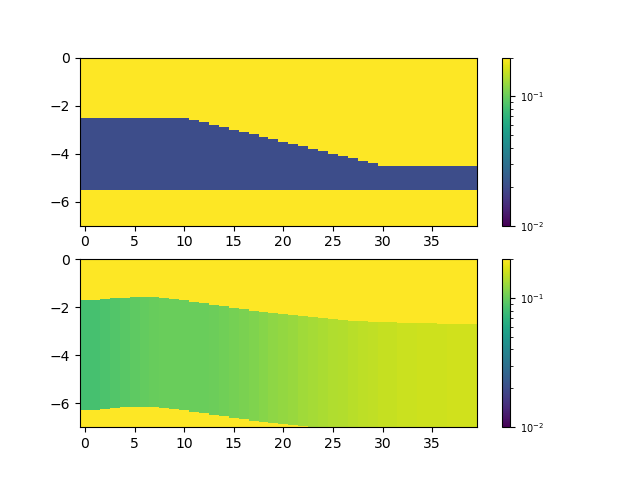

In [6]:
fig, ax = plt.subplots(2,1)

showStitchedModels(model_true, zMax = 7, ax=ax[0], cMin=20/2000, cMax=0.2)
showStitchedModels(model_inv, zMax = 7, ax=ax[1], cMin=20/2000, cMax=0.2)

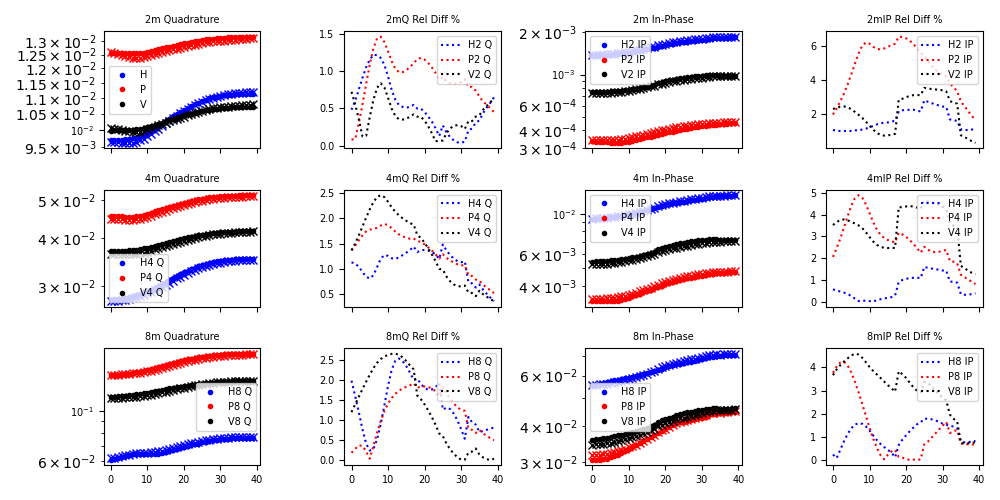

In [7]:
Plot2Datas(data_true, data_inv)